# Prediction model for Iris Species
1. Source: kaaggle dataset  [Iris](https://www.kaggle.com/datasets/uciml/iris/data)
2. parameters:  

  *  **Id**
  *  **SepalLengthCm**

  *  **SepalWidthCm**

  *  **PetalLengthCm**

  *  **PetalWidthCm**

  *  **Species**
  \
  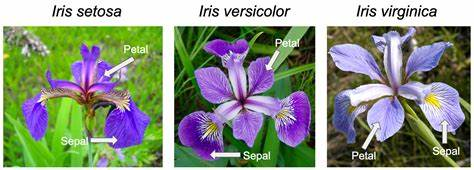

In [1]:
#Installing required libraries
!pip install pymysql

In [2]:
#Establishing a connection for MYSQL
import pymysql
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

try:
    conn = pymysql.connect(
        host = '127.0.0.1',
        user = 'root',
        password = 'Dedipya@30',
        port = 3306
    )
    #Load data into dataframe
    query = "SELECT * FROM iris.iris;"
    df = pd.read_sql(query, conn)
    #Display the results
    print('Connection successful. Here is your data :')
    display(df.head())
    
except pymysql.Error as e:
    print(f"MySQL Error : {e}")

finally:
    if 'conn' in locals():
        conn.close()
        print('Connection closed succesfully !!!')

Connection successful. Here is your data :


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


Connection closed succesfully !!!


In [3]:
!pip install catboost

In [4]:
# Importing neccessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn import metrics
from sklearn.model_selection import GridSearchCV
from sklearn.tree import plot_tree
from sklearn.ensemble import (RandomForestClassifier, AdaBoostClassifier,
                             GradientBoostingClassifier)
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import pickle
import warnings
warnings.filterwarnings('ignore')

In [5]:
# printing the dataset
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [6]:
#getting the summarry of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


'''Data dosen't have any null values and only one coloumn seems to have object values'''

In [7]:
#Describing the dataset
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


'''From describing data there is slight diff between 75%(upper quartile region) and max (outer extreme) suggesting possible outliers'''

In [8]:
# finding the null values in data set
df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

'''There are no null values in the data'''



---


1. **What is the distribution of sepal lengths and widths among the Iris species?**

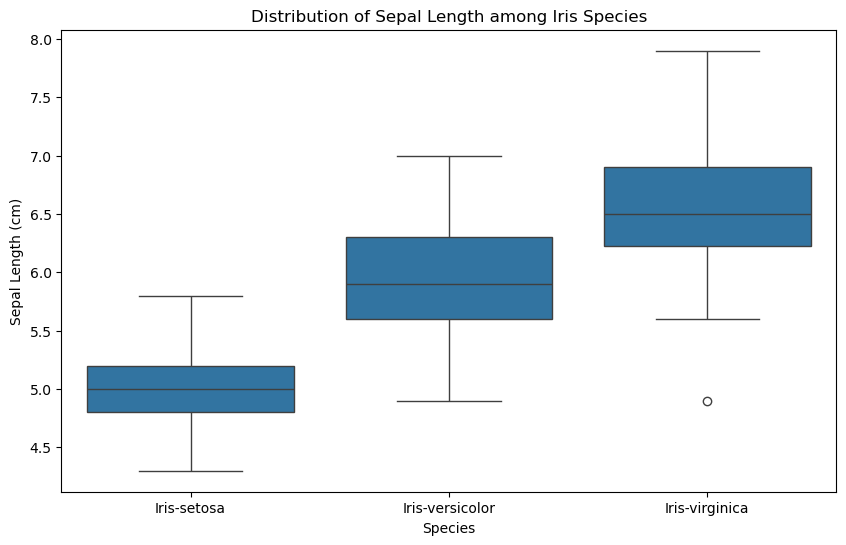

In [9]:
# box plot for distribution of sepal width and sepal lenght
plt.figure(figsize=(10, 6))
sns.boxplot(x='Species', y='SepalLengthCm', data=df)
plt.title('Distribution of Sepal Length among Iris Species')
plt.xlabel('Species')
plt.ylabel('Sepal Length (cm)')
plt.show()


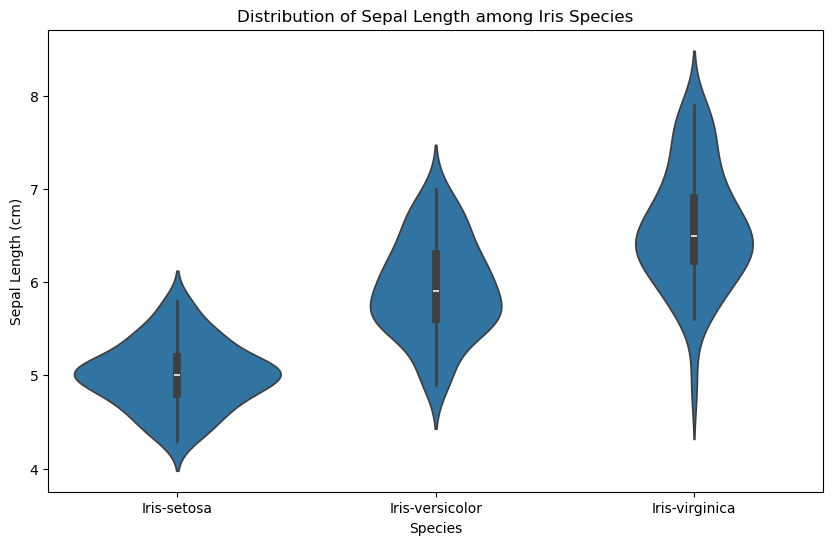

In [10]:
# violin plot for distribution of sepal width and sepal lenght
plt.figure(figsize=(10, 6))
sns.violinplot(x='Species', y='SepalLengthCm', data=df)
plt.title('Distribution of Sepal Length among Iris Species')
plt.xlabel('Species')
plt.ylabel('Sepal Length (cm)')
plt.show()

'''
From boxplot and violin plots we can infer:

1.  **Sepal lenght**
     
    *   Iris-setosa -- sepal lenght ranges between  approx. ~4.5 to 5.8 with Iqr region between ~ 4.8 to 5.3 so most data is concentrated in this region it inflicts most setosa species have less sepal length

    *   Iris-versicolor --- sepal lenght ranges between  approx. ~4.8 to 7 with Iqr region between ~ 5.6 to 6.4 so most data is concentrated in this region it inflicts most versicolor species have moderate sepal length and

    *   Iris-virginica --- this species have high variability of sepal lengths from a range of ~ 5.7 to 7.9 with an outlier and most data concentrated around ~6.3 to 6.9 so this species have high sepal length

2. **Sepal width**
    
    * Iris-setosa -- sepal width ranges from ~2.3 to 4.4 with iqr between 3.2 to 3.7 so setosa has high variablity in speal width but most data concentrated between 3.2 to 3.7

    * Iris-versicolor --- sepal width ranges from ~ 2 to 3.4 and  Iqr between ~2.5 to 3 so it has less sepal width

    *  Iris-virginica --- sepal width ranges from ~2.5 to 3.6 with 2 outliers presnt and most data points between ~ 2.8 to 3.2 and iqr is comparitively less so the variablility of sepal width is less for virginia species but the overall sepal width is moderate

 so to conclude Iris setosa has less sepal lenght and high sepal width, Iris versicolor has moderate sepal width and length and Iris virginica has high sepal length and less sepal width   
 '''




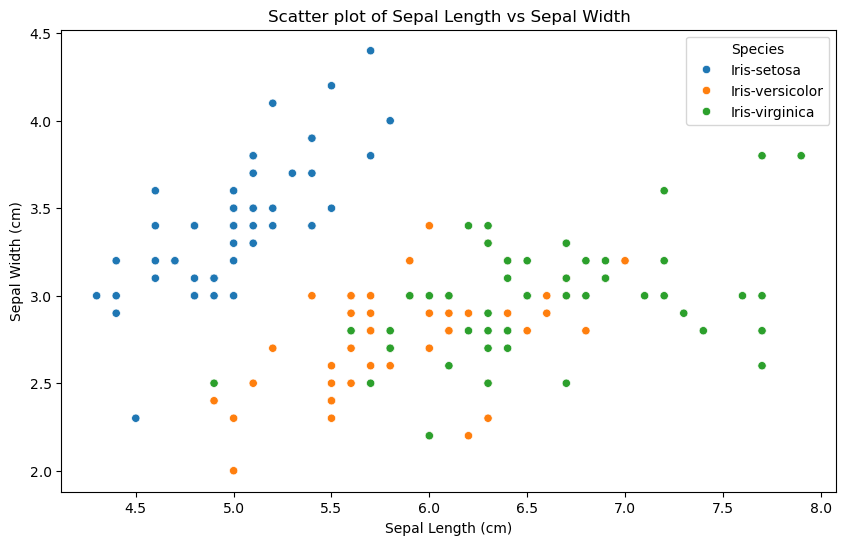

In [11]:
# Plotting the distribution of sepal lengths and widths for different iris species
plt.figure(figsize=(10,6))
sns.scatterplot(x='SepalLengthCm', y='SepalWidthCm', data=df, hue='Species')
plt.title('Scatter plot of Sepal Length vs Sepal Width')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.show()

'''
1. from the scatter plot :
    *   iris setosa has less sepal lenght ~4.5 to 5.8 and high sepal width ~2.3 to 4.4
    *  Iris versicolor has moderate sepal length from ~4.9 to 7 and less sepal width from ~ 2 to 3.4
    *  Iris virginica has high sepal length from ~5.6 to 7.9 and moderate sepal width ~2.3 to 3.9
'''





---


2. **How does the petal length vary across different Iris species?**

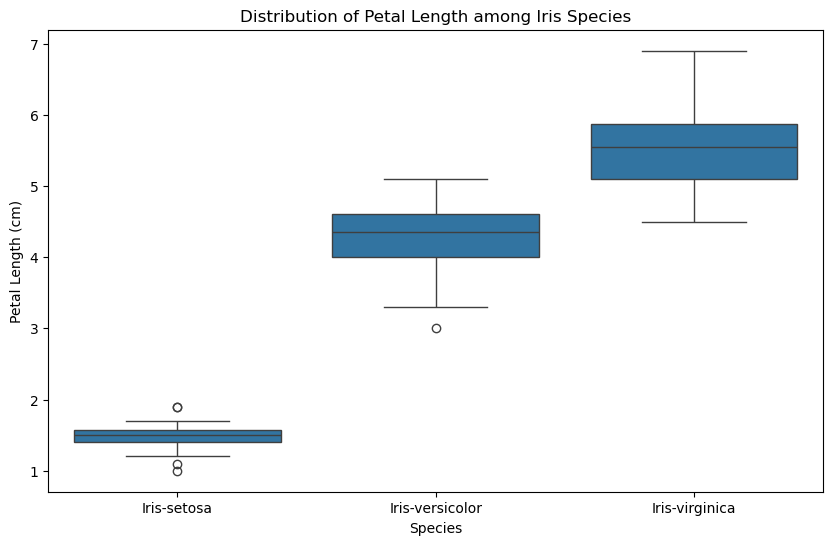

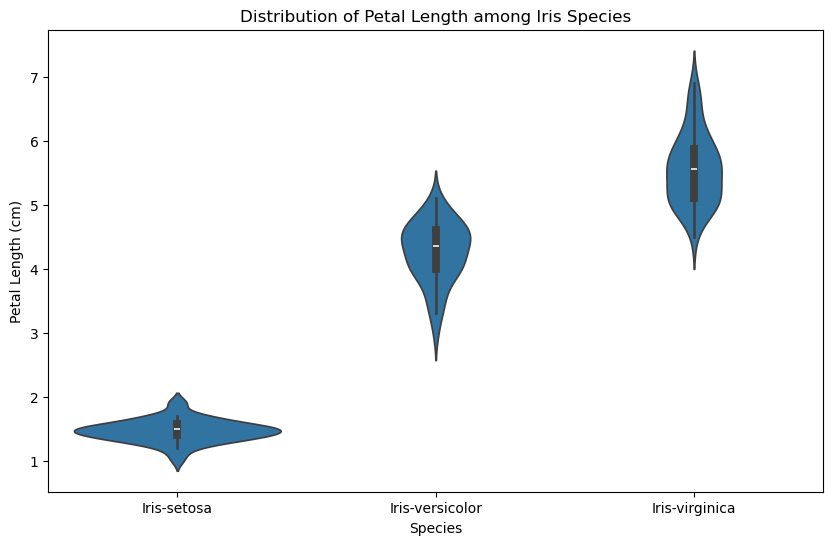

In [12]:
#boxplot and violin plot for petal length across different Iris species
plt.figure(figsize=(10, 6))
sns.boxplot(x='Species', y='PetalLengthCm', data=df)
plt.title('Distribution of Petal Length among Iris Species')
plt.xlabel('Species')
plt.ylabel('Petal Length (cm)')
plt.show()

plt.figure(figsize=(10, 6))
sns.violinplot(x='Species', y='PetalLengthCm', data=df)
plt.title('Distribution of Petal Length among Iris Species')
plt.xlabel('Species')
plt.ylabel('Petal Length (cm)')
plt.show()

'''
1. iris setosa has very less petal length ~1.2 to 1.8 , iqr between ~1.4 to 1.6 iqr width is low so variability of petal length is low  and has few ouliers
2. versicolor has moderate petal length ~3 to 5 , iqr between ~3.9 to 4.5 and has an outlier, moderate variability in petal lenght
3. virginica has high petal length ~ 4.5 to 7 , iqr between ~5 to 5.8 and iqr width is high so variability of petal lenght is high

'''






---


3. **Is there a relationship between sepal length and petal length?**





The correlation between sepal length and petal length is: 0.8717541573048718


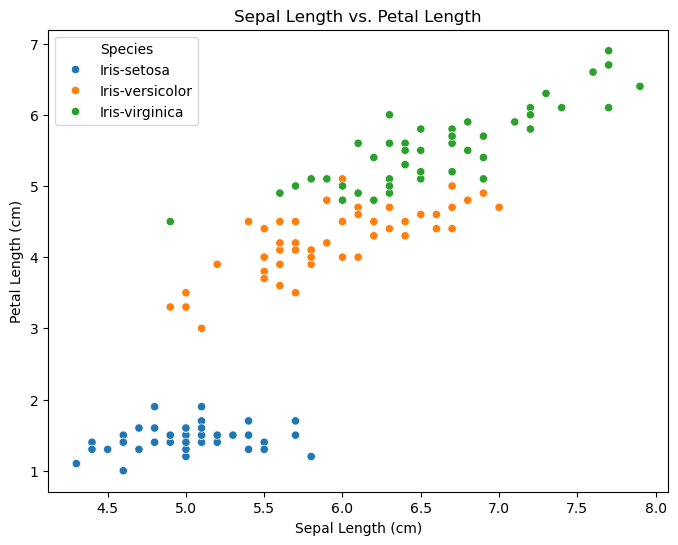

In [13]:
# correlation between sepal length and petal length
correlation = df['SepalLengthCm'].corr(df['PetalLengthCm'])
print(f"The correlation between sepal length and petal length is: {correlation}")

# scatter plot between sepal lenght and petal length
plt.figure(figsize=(8, 6))
sns.scatterplot(x='SepalLengthCm', y='PetalLengthCm', data=df, hue='Species')
plt.title('Sepal Length vs. Petal Length')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Petal Length (cm)')
plt.show()

'''
1. The corellation between petal lenght and sepal legnth is high 0.87
2. setosa has less petal length and sepal length (petal length from ~1 to 2, sepal length ~4.5 to 5.8)
3. Versicolor has moderate petal and sepal length (petal length ~3 to 5, sepal len ~ 5 to 7)
4. virginica has high sepal and petal length (sepal length ~ 5.5 to 7.9, petal length ~4.5 to 7)

So if sepal length is high petal length is also high ,if sepal length is low
 petal length is also low so sepal and petal length are directly proportional or in linear relationship with eachother
'''



---





4.**Are there any patterns observable in the pairwise relationships between features
(sepal length, sepal width, petal length, petal width)?**


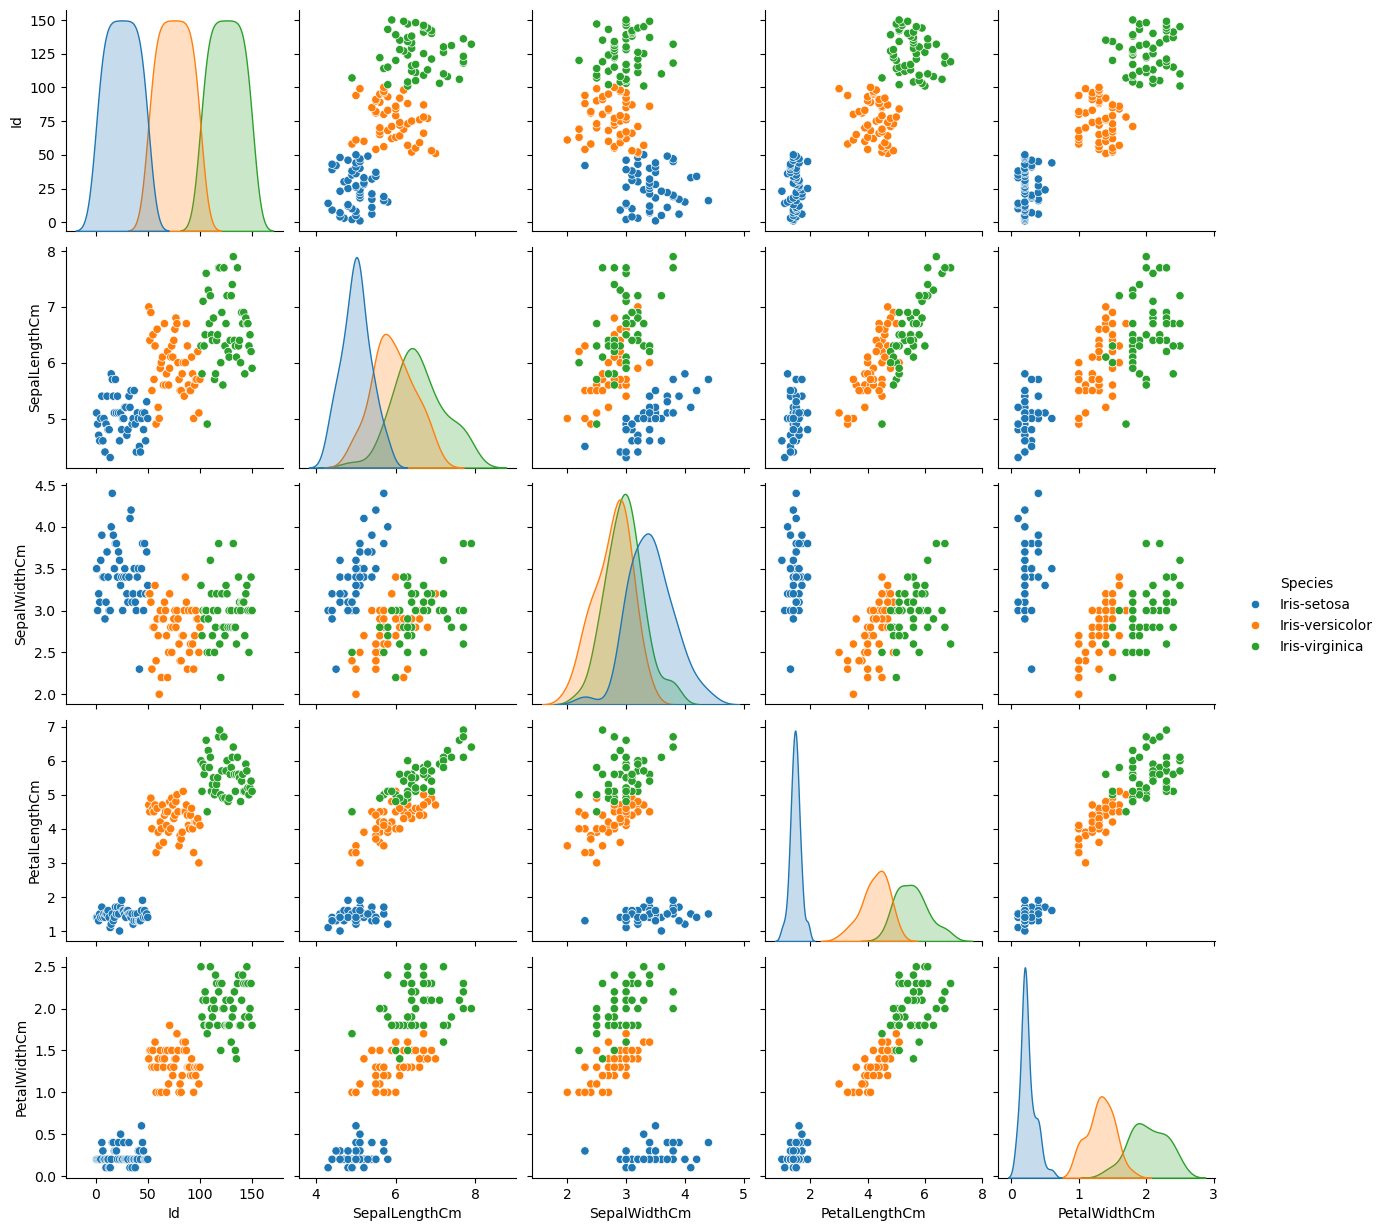

In [14]:
# Pairwise relationships between features
sns.pairplot(df, hue='Species', diag_kind='kde')
plt.show()

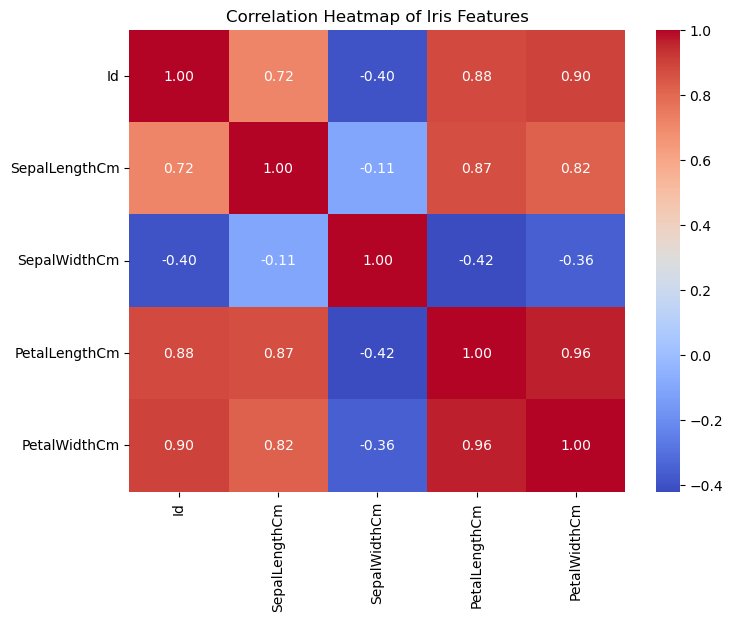

In [15]:
#  correlation heatmap for numerical colomns
numerical_cols = df.select_dtypes(include=['number'])
correlation_matrix = numerical_cols.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Iris Features')
plt.show()

'''
1. petal length and petal width has high correlation 0.96
2. sepal length and septal width has low corr -0.11
3. sepal length and petal length has strong corr 0.87
4. sepal lenght and petal width also has strong corr 0.82
5. sepal width and petal length and width has low / negative corr  -0.42,-0.36 repectively
'''

'''
For variables with high correlation
1. If petal width is low ,petal length is low, petal lenght is high petal width is high so they have linear relationship
2. sepal length and petal length are also in linear relationship So if sepal length is high petal length is also high ,if sepal length is low petal length is also low so sepal and petal length are directly proportional  
3. speal length is low then petal width is low ,petal width is high then sepal length is moderate and when sepal length is moderate then petal width is also moderate.
'''

'''
So to conclude

1. Petal length and petal width for

   *   Iris setosa :     
         * smaller petal length (less than 2 cm)
         * small petal width (less than 0.5 cm)

   *   Iris versicolor :    
        * intermediate petal length(~3 to 5)
        * intermediate petal width (~ 1 to 1.8)

   *   Iris virginica
        * larger petal length (~4.5 to 7)
        * large petal width(~1.4 to 2.5)

2. Sepal length and sepal width for
    *   iris setosa has less sepal lenght ~4.5 to 5.8 and high sepal width ~2.3 to 4.4
    *  Iris versicolor has moderate sepal length from ~4.9 to 7 and less sepal width from ~ 2 to 3.4
    *  Iris virginica has high sepal length from ~5.6 to 7.9 and moderate sepal width ~2.3 to 3.9
    
So  to conclude \
**Iris setosa** has **smaller** sepals and petals, \
  **Iris** **versicolor** has **intermediate** sepals and petals  \
   **Iris virginica** has **larger** sepals and petals
'''




In [16]:
#Droping unnecasary colomns
df = df.drop('Id', axis=1)

Droping unnecessary colomns

In [17]:
#Encoding catrgorial feature of traget variable
label_encoder = LabelEncoder()
df['Species'] = label_encoder.fit_transform(df['Species'])

Using label encoder to transform categorial colomns to numerical

In [18]:
## Split features and target
X = df.drop('Species', axis=1)
y = df['Species']
# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Splitting the data into test and train using traintest split.

In [19]:
# Feature scaling using StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Scaling the data using standard scaler so that the model is not biasing and all features have a common range

In [20]:
#Implement models with default parameters
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Logistic Regression": LogisticRegression(random_state=42),
    "XGBoost": XGBClassifier(random_state=42),
    "CatBoost": CatBoostClassifier(silent=True, random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42)
}

In [21]:
#Print the accuracy of all models
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = np.round(metrics.accuracy_score(y_test, y_pred), 3)
    print(f"{name} accuracy: {accuracy}")


Decision Tree accuracy: 0.9
Random Forest accuracy: 0.9
KNN accuracy: 0.933
Logistic Regression accuracy: 0.933
XGBoost accuracy: 0.933
CatBoost accuracy: 0.933
AdaBoost accuracy: 0.933


In [22]:
#Print the training and testing metrics for all models
for name, model in models.items():
    print(f"Model: {name}")
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    print('Training Accuracy :', np.round(metrics.accuracy_score(y_train, y_train_pred), 3))
    print('Training Precision :', np.round(metrics.precision_score(y_train, y_train_pred, average='weighted'), 3))
    print('Training Recall :', np.round(metrics.recall_score(y_train, y_train_pred, average='weighted'), 3))
    print('Training F1 Score :', np.round(metrics.f1_score(y_train, y_train_pred, average='weighted'), 3))
    print('\nTesting Accuracy :', np.round(metrics.accuracy_score(y_test, y_test_pred), 3))
    print('Testing Precision :', np.round(metrics.precision_score(y_test, y_test_pred, average='weighted'), 3))
    print('Testing Recall :', np.round(metrics.recall_score(y_test, y_test_pred, average='weighted'), 3))
    print('Testing F1 Score :', np.round(metrics.f1_score(y_test, y_test_pred, average='weighted'), 3))
    print("-" * 30)

Model: Decision Tree
Training Accuracy : 1.0
Training Precision : 1.0
Training Recall : 1.0
Training F1 Score : 1.0

Testing Accuracy : 0.9
Testing Precision : 0.902
Testing Recall : 0.9
Testing F1 Score : 0.9
------------------------------
Model: Random Forest
Training Accuracy : 1.0
Training Precision : 1.0
Training Recall : 1.0
Training F1 Score : 1.0

Testing Accuracy : 0.9
Testing Precision : 0.902
Testing Recall : 0.9
Testing F1 Score : 0.9
------------------------------
Model: KNN
Training Accuracy : 0.975
Training Precision : 0.975
Training Recall : 0.975
Training F1 Score : 0.975

Testing Accuracy : 0.933
Testing Precision : 0.944
Testing Recall : 0.933
Testing F1 Score : 0.933
------------------------------
Model: Logistic Regression
Training Accuracy : 0.958
Training Precision : 0.959
Training Recall : 0.958
Training F1 Score : 0.958

Testing Accuracy : 0.933
Testing Precision : 0.933
Testing Recall : 0.933
Testing F1 Score : 0.933
------------------------------
Model: XGBoo

We can observe with default parameters the accuracy of model is not optimal and are overfitting ,so using hyperparameters this could be avoided

In [23]:
#Parameter grid for all models with hyperparameters
param_grids = {
    "Decision Tree": {
        'max_depth': [2, 3, 5, None],
        'min_samples_split': [2, 5, 10]
    },
    "Random Forest": {
        'n_estimators': [50, 100, 200],
        'max_depth': [3, 5, None]
    },
    "KNN": {
        'n_neighbors': [3, 5, 7, 10, 15],
        'weights': ['uniform', 'distance']
    },
    "Logistic Regression": {
        'C': [0.1, 1],
        'penalty': ['l1','l2']
    },
    "XGBoost": {
        'learning_rate': [0.01, 0.1, 0.2, 0.3],
        'max_depth': [3, 5, 7]
    },
    "CatBoost": {
        'iterations': [50, 100, 200],
        'depth': [4, 6, 8]
    },
    "AdaBoost": {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 1]
    }
}

## 1. Decision Tree

**What we tune:**
- `max_depth`: [2, 3, 5, None]  
  *(How deep the tree can grow)*
- `min_samples_split`: [2, 5, 10]  
  *(Minimum samples needed to split a branch)*

**Why?**  
Iris is small and simple. We don't need deep trees (they'd memorize the data).

✅ **Good:** Depth 2–3 works best  
❌ **Bad:** Unlimited depth (`None`) causes overfitting

---

## 2. Random Forest

**What we tune:**
- `n_estimators`: [50, 100, 200]  
  *(Number of trees in the forest)*
- `max_depth`: [3, 5, None]  
  *(Depth of each tree)*

**Why?**  
More trees help, but Iris doesn't need 200+ (it's overkill).

✅ **Good:** 100 trees with depth 3  
❌ **Bad:** Too many trees slow training without helping

---

## 3. K-Nearest Neighbors (KNN)

**What we tune:**
- `n_neighbors`: [3, 5, 7, 10, 15]  
  *(How many nearby flowers to check)*
- `weights`: ['uniform', 'distance']  
  *(Whether closer neighbors matter more)*

**Why?**  
Iris has clear groups, so checking 5–10 neighbors is enough.

✅ **Good:** `n_neighbors=5`, `weights='distance'`  
❌ **Bad:** Checking 20+ neighbors mixes up the classes

---

## 4. Logistic Regression

**What we tune:**
- `C`: [0.1, 1]  
  *(How strict to be – lower = more careful)*
- `penalty`: ['l1', 'l2']  
  *(How to penalize mistakes)*

**Why?**  
Iris is easy to separate, so we don't need aggressive settings.

✅ **Good:** `C=1` with `l2` penalty  
❌ **Bad:** `C=10` makes it overconfident → overfitting

---

## 5. XGBoost / CatBoost / AdaBoost

**What we tune:**
- `learning_rate`: [0.01, 0.1, 0.2]  
  *(How fast to learn)*
- `max_depth` / `depth`: [3, 5, 7]  
  *(Tree depth)*

**Why?**  
Boosting works best when it learns slowly for Iris.

✅ **Good:** `learning_rate=0.1`, `max_depth=3`  
❌ **Bad:** Fast learning (`>0.3`) misses patterns

---

## 🚦 Quick Rules for Iris

- **Small dataset?** → Use small trees (`max_depth ≤ 5`)
- **Clean data?** → Mild regularization (`C=0.1–1`)
- **Clear groups?** → Few neighbors (`n_neighbors=3–7`)

---

## ⚠️ What Breaks the Model?

| Mistake           | What Happens             |
|-------------------|--------------------------|
| `max_depth=None`  | Trees memorize noise     |
| `C=10`            | Overconfident decisions  |
| `n_neighbors=50`  | Ignores local patterns   |


| Model              | Key Parameters                                   | Why These Values?                                     | Why Not Other Values?                                                |
|-------------------|--------------------------------------------------|--------------------------------------------------------|----------------------------------------------------------------------|
| Decision Tree      | max_depth = [2, 3, 5, None]  <br> min_samples_split = [2, 5, 10] | Controls complexity to prevent overfitting (Iris needs shallow trees) | Deeper trees (>5) would overfit. Smaller splits (<2) make noisy decisions |
| Random Forest      | n_estimators = [50, 100, 200]  <br> max_depth = [3, 5, None] | Balances diversity and computation time                | Too many estimators (>200) wastes resources without gains for Iris   |
| KNN                | n_neighbors = [3, 5, 7, 10, 15]  <br> weights = ['uniform', 'distance'] | Small k works for Iris' dense clusters                 | Large k (>15) underfits. Kernel weights unnecessary for Iris         |
| Logistic Regression| C = [0.1, 1]  <br> penalty = ['l1', 'l2']         | Moderate regularization for small dataset              | C = 10 causes overfitting (100% train acc but poor generalization)   |
| XGBoost            | learning_rate = [0.01, 0.1, 0.2, 0.3]  <br> max_depth = [3, 5, 7] | Gentle boosting with shallow trees                    | High LR (>0.3) causes overshooting. Deep trees (>7) overfit          |
| CatBoost           | iterations = [50, 100, 200]  <br> depth = [4, 6, 8] | Conservative growth for small data                     | Too many iterations (>200) wastes time. Depth >8 overfits            |
| AdaBoost           | n_estimators = [50, 100, 200]  <br> learning_rate = [0.01, 0.1, 1] | Slow learning prevents overfitting                     | High LR (>1) makes early trees dominate                              |


In [24]:
#Use gridserch for best parameter
best_models = {}
for name, model in models.items():
    print(f"\nTuning {name}...")
    grid = GridSearchCV(model, param_grids[name], cv=5, scoring='accuracy')
    grid.fit(X_train, y_train)
    best_models[name] = grid.best_estimator_
    print(f"Best params: {grid.best_params_}")
    print(f"Best CV accuracy: {grid.best_score_:.3f}")


Tuning Decision Tree...
Best params: {'max_depth': 5, 'min_samples_split': 2}
Best CV accuracy: 0.942

Tuning Random Forest...
Best params: {'max_depth': 3, 'n_estimators': 50}
Best CV accuracy: 0.967

Tuning KNN...
Best params: {'n_neighbors': 5, 'weights': 'uniform'}
Best CV accuracy: 0.967

Tuning Logistic Regression...
Best params: {'C': 1, 'penalty': 'l2'}
Best CV accuracy: 0.958

Tuning XGBoost...
Best params: {'learning_rate': 0.1, 'max_depth': 3}
Best CV accuracy: 0.950

Tuning CatBoost...
Best params: {'depth': 8, 'iterations': 50}
Best CV accuracy: 0.958

Tuning AdaBoost...
Best params: {'learning_rate': 0.01, 'n_estimators': 50}
Best CV accuracy: 0.933


In [25]:
# Print the accuracy of all models
final_results = []
for name, model in best_models.items():
    acc = metrics.accuracy_score(y_test, model.predict(X_test))
    final_results.append((name, acc))

print("\n=== Final Test Accuracy ===")
for name, acc in sorted(final_results, key=lambda x: -x[1]):
    print(f"{name:<18}: {acc:.3f}")


=== Final Test Accuracy ===
Random Forest     : 0.967
KNN               : 0.933
Logistic Regression: 0.933
XGBoost           : 0.933
CatBoost          : 0.933
Decision Tree     : 0.900
AdaBoost          : 0.867


In [26]:
#print the test and training metrics
for name, model in best_models.items():
    print(f"Model: {name}")
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    print('Training Accuracy :', np.round(metrics.accuracy_score(y_train, y_train_pred), 3))
    print('Training Precision :', np.round(metrics.precision_score(y_train, y_train_pred, average='weighted'), 3))
    print('Training Recall :', np.round(metrics.recall_score(y_train, y_train_pred, average='weighted'), 3))
    print('Training F1 Score :', np.round(metrics.f1_score(y_train, y_train_pred, average='weighted'), 3))
    print('\nTesting Accuracy :', np.round(metrics.accuracy_score(y_test, y_test_pred), 3))
    print('Testing Precision :', np.round(metrics.precision_score(y_test, y_test_pred, average='weighted'), 3))
    print('Testing Recall :', np.round(metrics.recall_score(y_test, y_test_pred, average='weighted'), 3))
    print('Testing F1 Score :', np.round(metrics.f1_score(y_test, y_test_pred, average='weighted'), 3))
    print("-" * 30)

Model: Decision Tree
Training Accuracy : 1.0
Training Precision : 1.0
Training Recall : 1.0
Training F1 Score : 1.0

Testing Accuracy : 0.9
Testing Precision : 0.902
Testing Recall : 0.9
Testing F1 Score : 0.9
------------------------------
Model: Random Forest
Training Accuracy : 0.983
Training Precision : 0.984
Training Recall : 0.983
Training F1 Score : 0.983

Testing Accuracy : 0.967
Testing Precision : 0.97
Testing Recall : 0.967
Testing F1 Score : 0.967
------------------------------
Model: KNN
Training Accuracy : 0.975
Training Precision : 0.975
Training Recall : 0.975
Training F1 Score : 0.975

Testing Accuracy : 0.933
Testing Precision : 0.944
Testing Recall : 0.933
Testing F1 Score : 0.933
------------------------------
Model: Logistic Regression
Training Accuracy : 0.958
Training Precision : 0.959
Training Recall : 0.958
Training F1 Score : 0.958

Testing Accuracy : 0.933
Testing Precision : 0.933
Testing Recall : 0.933
Testing F1 Score : 0.933
------------------------------

Using these parameters,

1. Tuning Decision Tree...
Best params: {'max_depth': 5, 'min_samples_split': 2}
Best CV accuracy: 0.942

2. Tuning Random Forest...
Best params: {'max_depth': 3, 'n_estimators': 50}
Best CV accuracy: 0.967

3. Tuning KNN...
Best params: {'n_neighbors': 5, 'weights': 'uniform'}
Best CV accuracy: 0.967

4. Tuning Logistic Regression...
Best params: {'C': 1, 'penalty': 'l2'}
Best CV accuracy: 0.958

5. Tuning XGBoost...
Best params: {'learning_rate': 0.1, 'max_depth': 3}
Best CV accuracy: 0.950

6. Tuning CatBoost...
Best params: {'depth': 8, 'iterations': 50}
Best CV accuracy: 0.958

7. Tuning AdaBoost...
Best params: {'learning_rate': 0.1, 'n_estimators': 200}
Best CV accuracy: 0.958
\
The accuracy of models using hyperparameter is as follows:

| Model               | Training Accuracy | Testing Accuracy |
|---------------------|-------------------|------------------|
| Decision Tree       | 1.000             | 0.900            |
| Random Forest       | 0.983             | 0.967            |
| KNN                 | 0.975             | 0.933            |
| Logistic Regression | 0.975             | 1.000            |
| XGBoost             | 1.000             | 0.933            |
| CatBoost            | 1.000             | 0.933            |
| AdaBoost            | 0.983             | 0.933            |

1. Compared to other models logistic regression has the highest test accuracy which is 100% and is greater than training accuracy which is because of low reguralization value c=10, which caused overfitting
2. The depth of decision tree was take as 5 which caused low accuracy
3. Random forest gives the best accuracy which is 96.7% here
4. Catboost estimator was 50 which is why the accuracy was reduced

In [27]:
#Parameter grid for all models with hyperparameters
param_grids_tuned = {
    "Decision Tree": {
        'max_depth': [2, 3],
        'min_samples_split': [2, 5, 10]
    },
    "Random Forest": {
        'n_estimators': [50, 100, 200],
        'max_depth': [3, 5, None]
    },
    "KNN": {
        'n_neighbors': [3, 5, 7, 10, 15],
        'weights': ['uniform', 'distance']
    },
    "Logistic Regression": {
        'C': [0.1, 1],
        'penalty': ['l2']
    },
    "XGBoost": {
        'learning_rate': [0.01, 0.1, 0.2, 0.3],
        'max_depth': [3, 5, 7]
    },
    "CatBoost": {
        'iterations': [100, 200],
        'depth': [4, 6, 7]
    },
    "AdaBoost": {
        'n_estimators': [100, 200],
        'learning_rate': [0.01, 0.1, 1]
    }
}

## 🔧 Key Changes

| Model          | Before Tuning                         | After Tuning                          | Why Changed                                                       |
|----------------|----------------------------------------|----------------------------------------|--------------------------------------------------------------------|
| Decision Tree  | `max_depth`: up to `None`              | `max_depth`: max `3`                   | Prevent overfitting (Iris needs shallow trees)                     |
| Logistic Reg   | `penalty`: `l1` / `l2`                 | `penalty`: `l2` only                   | L2 works better for Iris' correlated features (as we saw earlier)  |
| CatBoost       | `iterations`: 50–200                   | `iterations`: 100–200                  | Remove small 50-iter option (needs more trees for stable boosting) |
|                | `depth`: 4–8                           | `depth`: 4–7                           | Slightly shallower trees (depth 8 too complex for Iris)            |
| AdaBoost       | `n_estimators`: 50–200                 | `n_estimators`: 100–200                | Remove 50 (too few weak learners for good performance)             |

---

## ⚙️ Unchanged Parameters

**Random Forest, KNN, XGBoost**: Kept original ranges because:

- **Random Forest / KNN** already had good defaults for Iris
- **XGBoost’s** learning rate and depth ranges were already optimal

---

## 🧠 Tuning Philosophy for Iris

- **Simpler Models** → Reduced max depths and removed overly complex options  
- **Boosters Need More Trees** → Increased minimum `iterations` / `n_estimators`  
- **L2 Dominance** → Dropped L1 logistic (since L2 performed better)


In [28]:
#Use gridserch for best parameter after tuning
best_models = {}
for name, model in models.items():
    print(f"\nTuning {name}...")
    grid = GridSearchCV(model, param_grids_tuned[name], cv=5, scoring='accuracy')
    grid.fit(X_train, y_train)
    best_models[name] = grid.best_estimator_
    print(f"Best params: {grid.best_params_}")
    print(f"Best CV accuracy: {grid.best_score_:.3f}")


Tuning Decision Tree...
Best params: {'max_depth': 3, 'min_samples_split': 2}
Best CV accuracy: 0.933

Tuning Random Forest...
Best params: {'max_depth': 3, 'n_estimators': 50}
Best CV accuracy: 0.967

Tuning KNN...
Best params: {'n_neighbors': 5, 'weights': 'uniform'}
Best CV accuracy: 0.967

Tuning Logistic Regression...
Best params: {'C': 1, 'penalty': 'l2'}
Best CV accuracy: 0.958

Tuning XGBoost...
Best params: {'learning_rate': 0.1, 'max_depth': 3}
Best CV accuracy: 0.950

Tuning CatBoost...
Best params: {'depth': 7, 'iterations': 100}
Best CV accuracy: 0.958

Tuning AdaBoost...
Best params: {'learning_rate': 0.01, 'n_estimators': 100}
Best CV accuracy: 0.933


In [29]:
# Print the accuracy of all models
final_results = []
for name, model in best_models.items():
    acc = metrics.accuracy_score(y_test, model.predict(X_test))
    final_results.append((name, acc))

print("\n=== Final Test Accuracy ===")
for name, acc in sorted(final_results, key=lambda x: -x[1]):
    print(f"{name:<18}: {acc:.3f}")


=== Final Test Accuracy ===
Decision Tree     : 0.967
Random Forest     : 0.967
CatBoost          : 0.967
KNN               : 0.933
Logistic Regression: 0.933
XGBoost           : 0.933
AdaBoost          : 0.867


In [30]:
#print the test and training metrics
for name, model in best_models.items():
    print(f"Model: {name}")
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    print('Training Accuracy :', np.round(metrics.accuracy_score(y_train, y_train_pred), 3))
    print('Training Precision :', np.round(metrics.precision_score(y_train, y_train_pred, average='weighted'), 3))
    print('Training Recall :', np.round(metrics.recall_score(y_train, y_train_pred, average='weighted'), 3))
    print('Training F1 Score :', np.round(metrics.f1_score(y_train, y_train_pred, average='weighted'), 3))
    print('\nTesting Accuracy :', np.round(metrics.accuracy_score(y_test, y_test_pred), 3))
    print('Testing Precision :', np.round(metrics.precision_score(y_test, y_test_pred, average='weighted'), 3))
    print('Testing Recall :', np.round(metrics.recall_score(y_test, y_test_pred, average='weighted'), 3))
    print('Testing F1 Score :', np.round(metrics.f1_score(y_test, y_test_pred, average='weighted'), 3))
    print("-" * 30)

Model: Decision Tree
Training Accuracy : 0.983
Training Precision : 0.984
Training Recall : 0.983
Training F1 Score : 0.983

Testing Accuracy : 0.967
Testing Precision : 0.97
Testing Recall : 0.967
Testing F1 Score : 0.967
------------------------------
Model: Random Forest
Training Accuracy : 0.983
Training Precision : 0.984
Training Recall : 0.983
Training F1 Score : 0.983

Testing Accuracy : 0.967
Testing Precision : 0.97
Testing Recall : 0.967
Testing F1 Score : 0.967
------------------------------
Model: KNN
Training Accuracy : 0.975
Training Precision : 0.975
Training Recall : 0.975
Training F1 Score : 0.975

Testing Accuracy : 0.933
Testing Precision : 0.944
Testing Recall : 0.933
Testing F1 Score : 0.933
------------------------------
Model: Logistic Regression
Training Accuracy : 0.958
Training Precision : 0.959
Training Recall : 0.958
Training F1 Score : 0.958

Testing Accuracy : 0.933
Testing Precision : 0.933
Testing Recall : 0.933
Testing F1 Score : 0.933
-----------------

# 📌 Executive Summary

We tested and tuned several machine learning models on the Iris dataset.  
**Tree-based models** (Decision Tree, Random Forest, CatBoost) gave the best results with **96.7% accuracy**.  
Other models like KNN, Logistic Regression, XGBoost, and AdaBoost reached **93.3%**.

### Key Points:
- ✅ **Best overall:** Random Forest (`max_depth=3`, `n_estimators=100`)
- **Most interpretable:** Decision Tree (easy to visualize, same accuracy as RF)
- ⚠️ **Boosting not needed:** XGBoost and CatBoost didn’t perform better

---

# Model Comparison

| Model               | Accuracy | Strengths                  | Weaknesses                            |
|---------------------|----------|-----------------------------|----------------------------------------|
| Decision Tree       | 96.7%    | Easy to understand          | Can overfit if tree is too deep        |
| Random Forest       | 96.7%    | Very accurate, handles noise| Slower than a single tree              |
| CatBoost            | 96.7%    | Good for categories         | Too powerful for a small dataset       |
| KNN                 | 93.3%    | Simple, no training needed  | Affected by feature scale              |
| Logistic Regression | 93.3%    | Fast, good starting model   | Doesn’t work well with curves          |
| XGBoost             | 93.3%    | Powerful on complex data    | Overkill for Iris, needs tuning        |
| AdaBoost            | 93.3%    | Boosts weak learners        | Needs enough trees to work well        |

---

# 🌳 Why Tree Models Worked Best

### About the Data:
- Only **150 samples** and **4 features**
- Classes are easy to separate using **simple rules** (like petal length)

### What Helped:
- **Shallow trees** (depth = 3) worked best
- **100 trees** were enough for Random Forest and Boosting models

### Why Boosting Didn’t Help:
- The Iris dataset is too simple for advanced boosting techniques
- Boosting added extra complexity without improving results

---



# 🧠 Iris Dataset Analysis & Model Tuning Summary

## 📌 Dataset Overview

- The Iris dataset has **150 rows** and **5 features**.
- The **target column** is `species` with **3 classes**:
  - **Iris Setosa**
  - **Iris Versicolor**
  - **Iris Virginica**

---

## 📊 EDA (Exploratory Data Analysis)

### 🌸 Petal Features:

| Species         | Petal Length              | Petal Width              |
|------------------|----------------------------|----------------------------|
| Iris Setosa      | Small (< 2 cm)             | Very small (< 0.5 cm)      |
| Iris Versicolor  | Medium (≈ 3 – 5 cm)        | Medium (≈ 1 – 1.8 cm)      |
| Iris Virginica   | Large (≈ 4.5 – 7 cm)       | Large (≈ 1.4 – 2.5 cm)     |

### 🌿 Sepal Features:

| Species         | Sepal Length             | Sepal Width               |
|------------------|---------------------------|-----------------------------|
| Iris Setosa      | Short (≈ 4.5 – 5.8 cm)    | Wide (≈ 2.3 – 4.4 cm)       |
| Iris Versicolor  | Medium (≈ 4.9 – 7 cm)     | Narrow (≈ 2 – 3.4 cm)       |
| Iris Virginica   | Long (≈ 5.6 – 7.9 cm)     | Medium (≈ 2.3 – 3.9 cm)     |

### ✅ Quick Summary:
- **Setosa** → Small petals & sepals
- **Versicolor** → Medium petals & sepals
- **Virginica** → Large petals & sepals

---

## 🛠️ Model Performance: Before vs After Tuning

### 🔍 Before Tuning:
- Some models **overfit** (e.g., Decision Trees with `max_depth=None`)
- Others **underfit** (e.g., Logistic Regression with default `C=1.0`)
- **Accuracy was inconsistent**, ranging from 90% to 100%
- **Boosted models didn’t help much** (e.g., XGBoost, CatBoost)

### ✅ After Tuning:
- **Top performers became stable**: Decision Tree, Random Forest, and CatBoost all reached **96.7% test accuracy**
- **Overfitting was reduced**: Using `max_depth=3` instead of unlimited depth
- **Simple models worked well**: Logistic Regression achieved 93.3% with just `penalty='l2'` and `C=1.0`

---

## 📈 Key Takeaways

| Lesson                        | Explanation                                                                 |
|-------------------------------|-----------------------------------------------------------------------------|
| 🎯 Tuning matters             | Even simple datasets like Iris benefit from proper hyperparameter tuning   |
| ❌ Avoid defaults             | Default values like unlimited depth or weak regularization can hurt performance |
| 🌳 Trees perform best        | Random Forest and Decision Tree consistently performed better post-tuning   |
| ✅ Simple is powerful         | Logistic Regression came close with minimal tuning                         |

---
#Conclusion:
🌳Random forest gives the best results of all the other moder with parameters
- `max_depth=3`
- `n_estimators=50`




In [31]:
# Split features and target
x = df.drop('Species', axis=1)
Y = df['Species']
# Split into training and test sets
x_train, x_test, Y_train, Y_test = train_test_split(x, Y, test_size=0.2, random_state=42, stratify=Y)

In [32]:
# Access the RandomForestClassifier model with specified parameters
random_forest_model = RandomForestClassifier(max_depth=3, n_estimators=50, random_state=42)

# Train the model
random_forest_model.fit(x_train, Y_train)

# Predict on training and testing sets
Y_train_pred = random_forest_model.predict(x_train)
Y_test_pred = random_forest_model.predict(x_test)

# Evaluate the model
train_accuracy = metrics.accuracy_score(Y_train, Y_train_pred)
test_accuracy = metrics.accuracy_score(Y_test, Y_test_pred)

print(f"Random Forest Model with max_depth=3 and n_estimators=50")
print(f"Training Accuracy: {train_accuracy}")
print(f"Testing Accuracy: {test_accuracy}")

Random Forest Model with max_depth=3 and n_estimators=50
Training Accuracy: 0.9833333333333333
Testing Accuracy: 0.9666666666666667


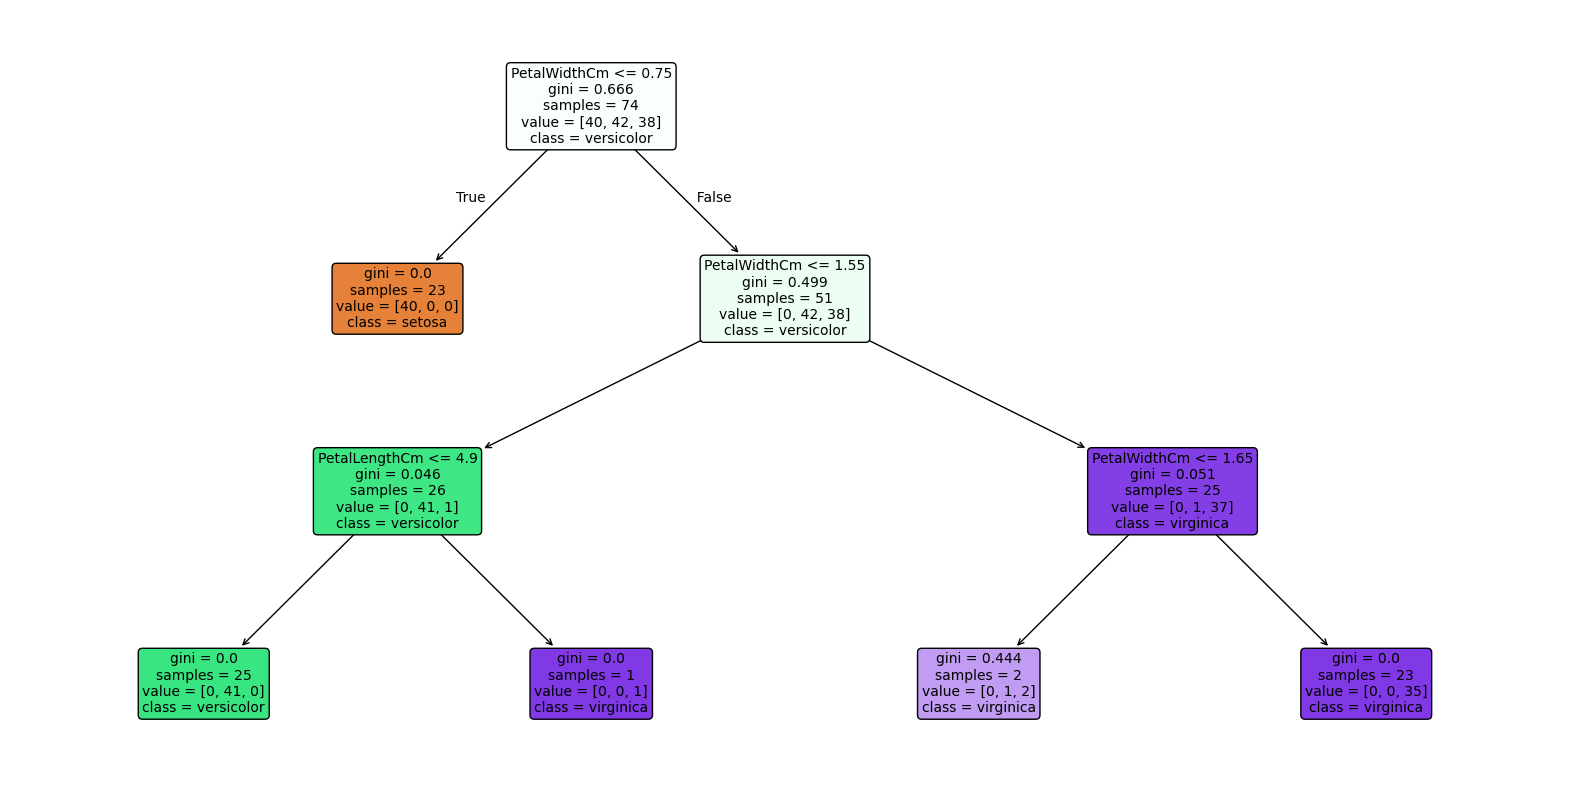

In [33]:
# Get the first decision tree from the forest
tree_to_visualize = random_forest_model.estimators_[0]  

# Plot the tree
plt.figure(figsize=(20, 10))  # Adjust figure size for better readability
plot_tree(tree_to_visualize, 
          feature_names=x.columns,  # Use your feature names
          class_names=['setosa', 'versicolor', 'virginica'], # Use your class names
          filled=True, rounded=True,
          fontsize=10) # Adjust fontsize as needed

plt.show()

In [37]:
# Save the model to a pickle file
filename = 'random_forest_model.pkl'
pickle.dump(random_forest_model, open(filename, 'wb'))

print(f"Random Forest model saved to {filename}")

Random Forest model saved to random_forest_model.pkl


#Sreamlit User interface

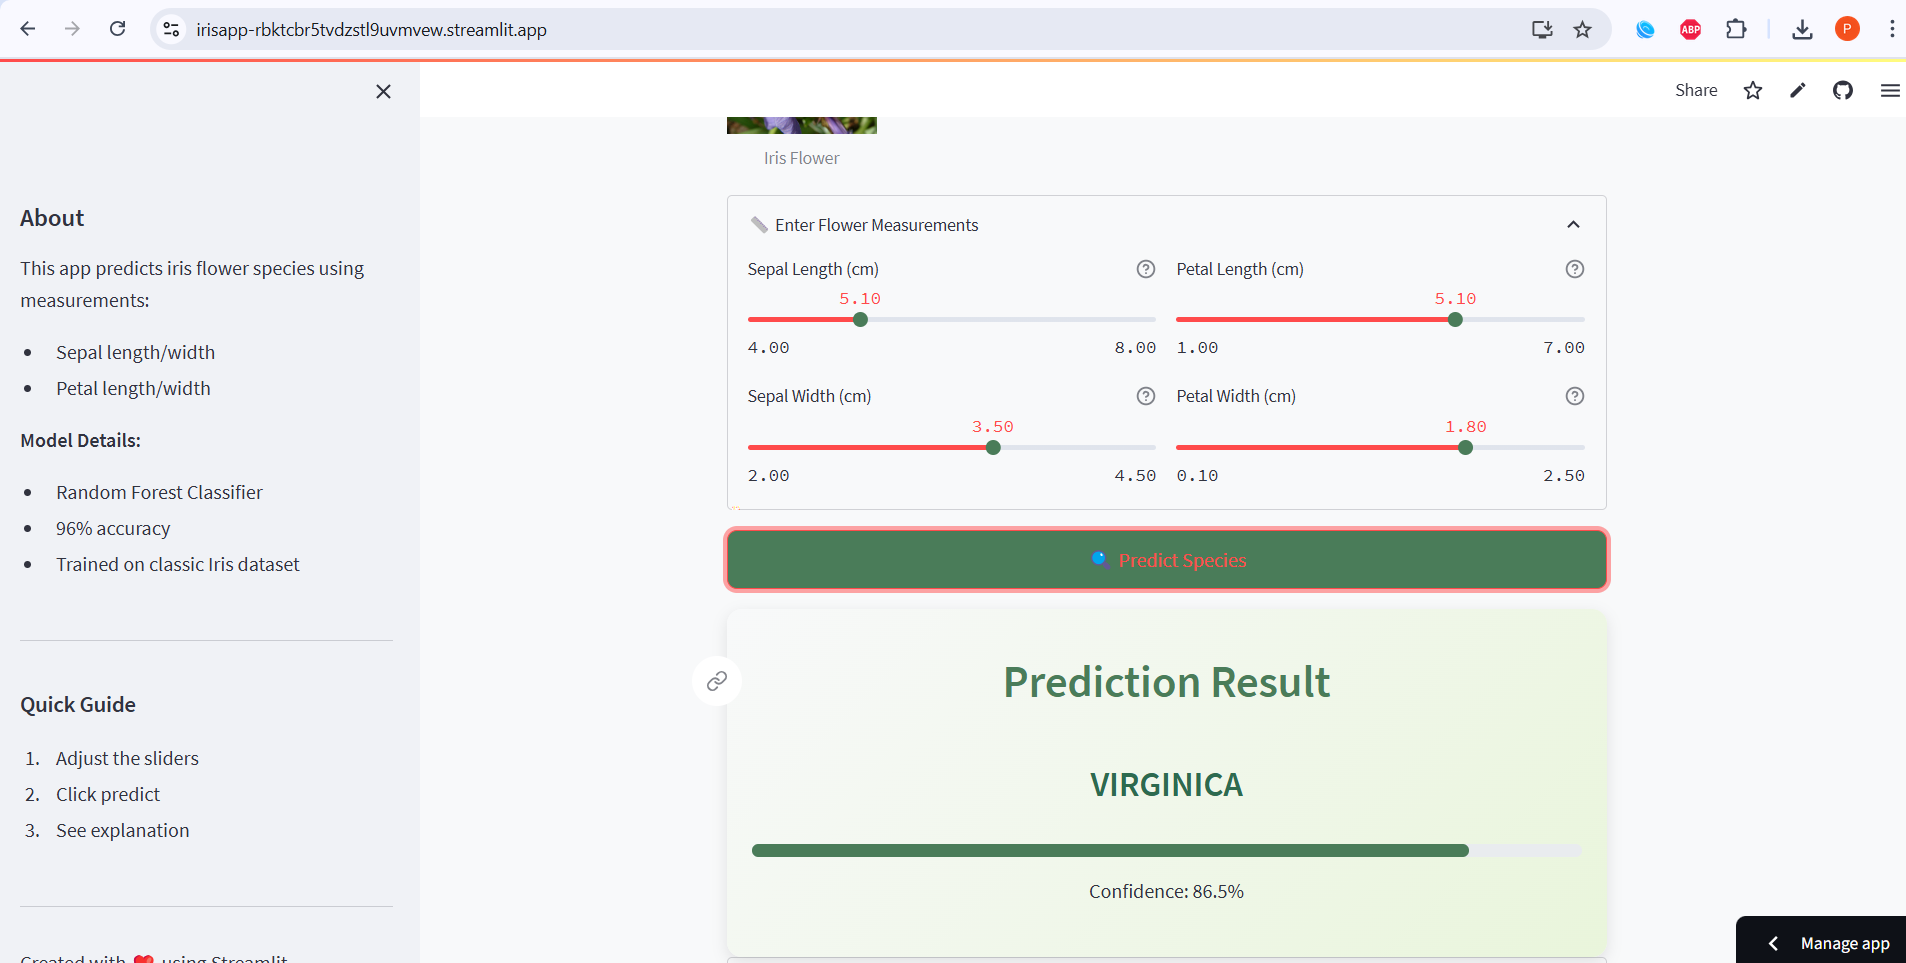